## Model Training On Real Data

In [ ]:
# import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

In [2]:
# Get absolute path to project root
project_root = os.path.abspath("..")

# Add to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)

### Load Dataset

In [3]:
transactions_data = pd.read_csv("data/credit_card_data_real.zip", compression="zip")
transactions_data = transactions_data.drop_duplicates()

print(transactions_data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## Class Imbalance

As it can be seen here there is a class imbalance poblem with the dataset. The fraudulent transactions are only 492 or less than 1% of the entire dataset

In [4]:
print(transactions_data["Class"].value_counts())
print()
print(transactions_data["Class"].value_counts(normalize=True))

Class
0    283253
1       473
Name: count, dtype: int64

Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


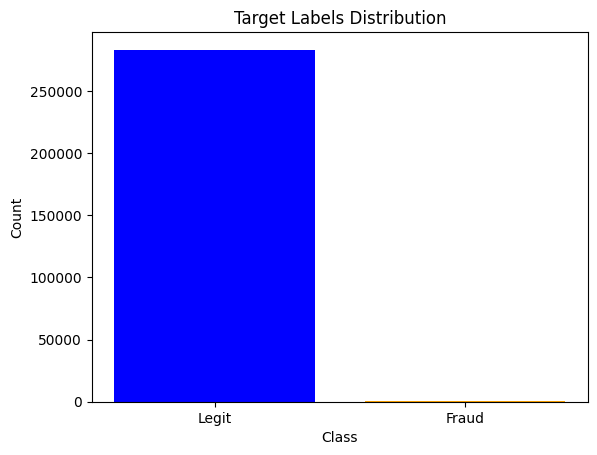

In [5]:
from src.utils import plot_confusion_matrix_from_pipeline, plot_label_distribution, plot_roc_curve_from_pipeline

plot_label_distribution(transactions_data["Class"], "Target Labels Distribution")

## Data Preparation

### Data Resampling

As seen before the data has to be resampled to mitigate the class imbalance problem. SMOTE is used again to over-sample the minority class

In [6]:
from imblearn.over_sampling import SMOTE

X = transactions_data.drop(["Class"], axis=1)
y = transactions_data["Class"]

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

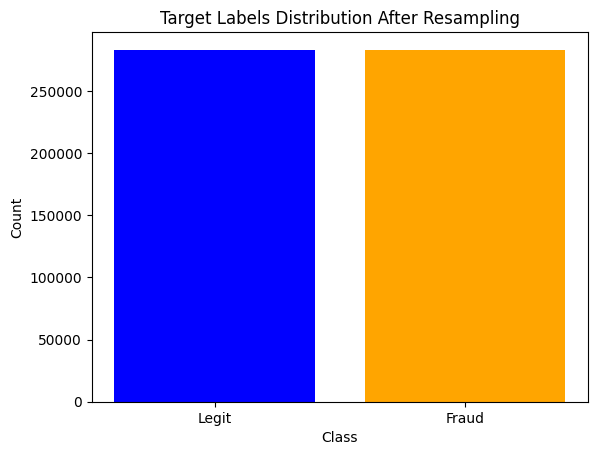

In [7]:
plot_label_distribution(y_resampled, "Target Labels Distribution After Resampling")

## Model Building

It's time to try a few machine learning models and see how they perform on real data.

In [8]:
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

### Evaluation Metrics

Given the imbalnced dataset, some suitable metrics are __ROC AUC__ score, __average precision__ score and __f1__ score.

- **ROC AUC**: is the area under the Receiver Operating Characteristic curve

- **average precision**: summarizes a precision-recall curve as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

$$ AP = \sum(R_n - R_{n - 1})P_n $$

  where $P_n$ and $ R_n $ are the precision and recall at the nth threshold 

- **f1 score**: is the harmonic mean of precision and recall
$$ F1 = \frac{2 * TP}{2 * TP + FP + FN} $$

### Logistic Regression

Bellow a pipeline was created with StandardScaler, SMOTE over-sampling and a LogisticRegression model. The model was trained using stratified cross-validation and achived a roc_aus score of 98%, average precision score of 73% and f1 score of 10%

In [9]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from src.utils import cross_validate_pipeline

# Define components 
scaler = StandardScaler()
log_reg = LogisticRegression(random_state=42, class_weight="balanced")

# Define pipeline
log_reg_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", log_reg)
    ]
)

# Cross-validation Iterator
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics
scoring = {
    "roc_aus": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1"
}

# Run cv
cross_validate_pipeline(log_reg_pipeline, X, y, cv, scoring_metrics=scoring)

roc_aus: 0.9773
pr_auc: 0.7324
f1: 0.1049


### Stochastic Gradient Descent Classifier

The SGDClassifier pipeline achived a roc auc score of 98%, an average precision score of 73% and a f1 score of 10%. It prerforms identical to the Logistic Regression pipeline

In [10]:
sgd_clf = SGDClassifier(random_state=42, class_weight="balanced")

sgd_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", sgd_clf)
    ]
)

cross_validate_pipeline(sgd_pipeline, X, y, cv, scoring)

roc_aus: 0.9795
pr_auc: 0.7309
f1: 0.1041


### Gradient Boosting Classifier

The Gradient Boosting Classifier pipieline achived a roc_auc score of 95%, 75% average precision score and 61% f1 score. It has slightly lower roc auc score then the SGDClassifier but higher f1 score and average precision score

In [11]:
gb_clf = HistGradientBoostingClassifier(random_state=42)

gb_clf_pipeline = ImbPipeline(
    steps=[
        ("scaler", scaler),
        ("smote", smote),
        ("model", gb_clf)
    ]
)

cross_validate_pipeline(gb_clf_pipeline, X, y, cv, scoring)

roc_aus: 0.9581
pr_auc: 0.7543
f1: 0.6147


## Hyper-parameter Tuning

### Logistic Regression

After hyper-parameter tuning, the best LogisticRegression model achived an average precision score of 74% which is slightly better than the model with default hyper-parameters

In [16]:
from src.utils import tune_pipeline_hyper_parameters

param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__C": [0.001, 0.01, 0.1, 1, 10],
    "model__fit_intercept": [False, True],
    "model__class_weight": [None, "balanced"]
}

best_model, best_params, best_score = tune_pipeline_hyper_parameters(
    log_reg_pipeline, 
    param_dist, 
    10, 
    cv, 
    "average_precision", 
    X, y
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [17]:
print(f"Best hyper-parameters: {best_params}")
print(f"Best score: {best_score:.4f}")

Best hyper-parameters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 3, 'model__fit_intercept': True, 'model__class_weight': None, 'model__C': 10}
Best score: 0.7403


### Stochastic Gradient Descent Classifier

The best Stochastic Gradient Descent model achived an average precision score of 73% which is lower the the best Logistic Regrssion model.

In [20]:
param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__alpha": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1],
    "model__loss": ["hinge", "log_loss"],
}

best_model, best_params, best_score = tune_pipeline_hyper_parameters(
    sgd_pipeline, 
    param_dist, 
    20,
    cv, 
    "average_precision",
    X, y,
)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [21]:
print(f"Best hyper-parameters: {best_params}")
print(f"Best score: {best_score:.4f}")

Best hyper-parameters: {'smote__sampling_strategy': 0.5, 'smote__k_neighbors': 3, 'model__loss': 'log_loss', 'model__alpha': 1e-05}
Best score: 0.7346


### Gradient Boosting Classifier

The best Gradient Bosting Classifier achived an average precision similar to the best Logistic Regression model but slightly lower than the Gradient Boosting Classifier with default hyper-parameters. Additionally this model takes a lot of time to tune.

In [22]:
param_dist = {
    "smote__k_neighbors": [3, 5, 7],
    "smote__sampling_strategy": [0.2, 0.5, 1.0],
    "model__learning_rate": np.arange(0.01, 0.02, 0.01),
    "model__max_depth": [3, 5, 7, 9]
}

best_model, best_params, best_score = tune_pipeline_hyper_parameters(
    gb_clf_pipeline,
    param_dist,
    10,
    cv, 
    "average_precision",
    X, y
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [23]:
print(f"Best hyper-parameters: {best_params}")
print(f"Best score: {best_score:.4f}")

Best hyper-parameters: {'smote__sampling_strategy': 0.2, 'smote__k_neighbors': 5, 'model__max_depth': 9, 'model__learning_rate': np.float64(0.01)}
Best score: 0.7394


## Final Evaluation

The best model so far seems to be the Gradient Bossting Classifier. Bellow the model is evaluated on unseen data and achived a f1 score of 61%, average precision score of 47% and roc auc score of 96%.

In [12]:
from src.utils import evaluate_pipeline, split_data

# Train-test split with stratification
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)
gb_clf_pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'


In [13]:
evaluate_pipeline(gb_clf_pipeline, X_test, y_test)

Test set f1 score: 0.6753
Test set average precision: 0.4712
Test set roc auc score: 0.9706


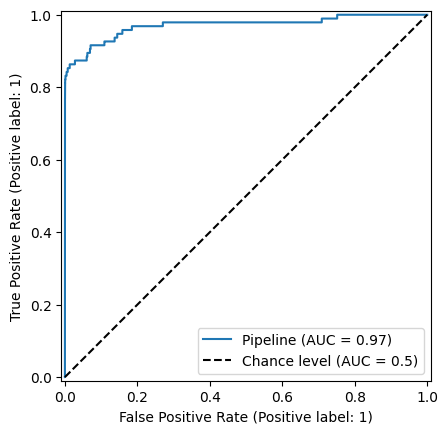

In [15]:
plot_roc_curve_from_pipeline(gb_clf_pipeline, X_test, y_test, plot_chance_level=True)

As seen from the confusion matrix bellow, the model corectly classifed 78 samples from the test set as fraudulent and 56593 samples as legit transctions. The false negatives are an acceptable amount (17) but there are a lot of false positives (58).

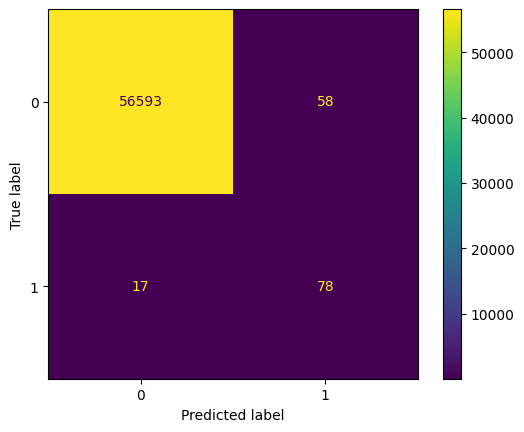

In [16]:
plot_confusion_matrix_from_pipeline(gb_clf_pipeline, X_test, y_test)

## Tuning Classifiation Threshold

The optimal classifiction threshold is 97%. This means that if a transction has greater than 97% probability of being fraudulent it will be classified as fraud. The thresholded Gradient Boosting Classifier acived a f1 score of 80%, an average precision score of 64% and a roc auc score of 97%. 

In [19]:
from src.utils import tune_classification_threshold

thresholded_gb_clf = tune_classification_threshold(gb_clf_pipeline, X_train, y_train, "average_precision", cv)

Cut-off point found at 0.970


In [20]:
evaluate_pipeline(thresholded_gb_clf, X_test, y_test)

Test set f1 score: 0.8000
Test set average precision: 0.6495
Test set roc auc score: 0.9706


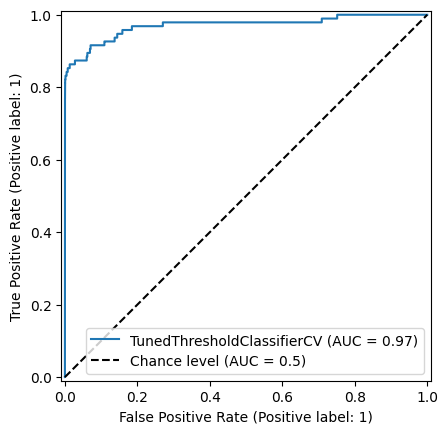

In [22]:
plot_roc_curve_from_pipeline(thresholded_gb_clf, X_test, y_test, plot_chance_level=True)

As seen from the confusion matrix bellow the thresholded classifer makes less false positive classifications but the higher threshold also introduced more false negatives.

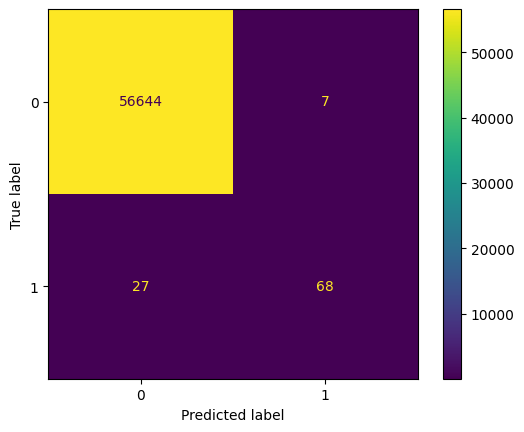

In [23]:
plot_confusion_matrix_from_pipeline(thresholded_gb_clf, X_test, y_test)